# Heart Disease UCI Dataset - Exploratory Data Analysis

This notebook performs comprehensive EDA on the **UCI Heart Disease (Cleveland) dataset**, a well-known benchmark dataset for binary classification in healthcare ML.

## Objectives
- **Data Acquisition**: Load and verify the Cleveland Heart Disease dataset
- **Data Quality Assessment**: Check for missing values, duplicates, and data types
- **Feature Exploration**: Understand distributions of numeric and categorical features
- **Correlation Analysis**: Identify relationships between features and the target variable
- **Class Balance**: Examine the distribution of heart disease presence/absence

## Dataset Overview
The dataset contains **303 patient records** with **13 clinical features** and **1 target variable** indicating heart disease presence. This is a binary classification problem where we predict whether a patient has heart disease (1) or not (0).

## Setup and Dependencies
The following libraries are used in this analysis:
- **pandas/numpy**: Data manipulation and numerical operations
- **matplotlib/seaborn**: Data visualization with statistical plots
- **pathlib**: Cross-platform file path handling

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Configure display settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading

The data loading step uses a custom download function from our `src.data.download` module. This function:
1. Checks if the dataset already exists locally
2. Downloads from UCI ML Repository if needed
3. Performs basic preprocessing (column renaming, missing value handling)
4. Saves to `data/raw/heart_cleveland.csv`

This approach ensures **reproducibility** - the same data is used across all experiments.

In [2]:
# Import download function
import sys
sys.path.insert(0, '..')

from src.data.download import download_cleveland_dataset, get_project_root

# Download dataset if not exists
project_root = get_project_root()
data_path = project_root / 'data' / 'raw' / 'heart_cleveland.csv'

if not data_path.exists():
    print("Downloading dataset...")
    df = download_cleveland_dataset()
else:
    print(f"Loading data from {data_path}")
    df = pd.read_csv(data_path)

print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape}")

Loading data from C:\Users\Rajkumar Madhavan\OneDrive\Desktop\MLOPS\MLOPS-Assignment\notebooks\..\data\raw\heart_cleveland.csv

Dataset loaded successfully!
Shape: (303, 14)


In [3]:
# Feature descriptions
FEATURE_DESCRIPTIONS = {
    'age': 'Age in years',
    'sex': 'Sex (1 = male; 0 = female)',
    'cp': 'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol': 'Serum cholesterol (mg/dl)',
    'fbs': 'Fasting blood sugar > 120 mg/dl',
    'restecg': 'Resting ECG results (0-2)',
    'thalach': 'Maximum heart rate achieved',
    'exang': 'Exercise induced angina',
    'oldpeak': 'ST depression by exercise',
    'slope': 'Slope of peak exercise ST segment',
    'ca': 'Number of major vessels (0-3)',
    'thal': 'Thalassemia type',
    'target': 'Heart disease presence (0/1)'
}

for feature, description in FEATURE_DESCRIPTIONS.items():
    print(f"{feature:12} : {description}")

age          : Age in years
sex          : Sex (1 = male; 0 = female)
cp           : Chest pain type (0-3)
trestbps     : Resting blood pressure (mm Hg)
chol         : Serum cholesterol (mg/dl)
fbs          : Fasting blood sugar > 120 mg/dl
restecg      : Resting ECG results (0-2)
thalach      : Maximum heart rate achieved
exang        : Exercise induced angina
oldpeak      : ST depression by exercise
slope        : Slope of peak exercise ST segment
ca           : Number of major vessels (0-3)
thal         : Thalassemia type
target       : Heart disease presence (0/1)


## 2. Initial Data Inspection

Before any analysis, we examine:
- **Data shape**: Number of samples (rows) and features (columns)
- **Data types**: Numeric vs categorical, integer vs float
- **Sample records**: Visual inspection of actual values
- **Statistical summary**: Mean, std, min, max, quartiles

This initial inspection helps identify potential data quality issues early.

In [4]:
# Display first few rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [5]:
# Basic information
print("Dataset Info:")
print("=" * 50)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [6]:
# Statistical summary
print("Statistical Summary:")
print("=" * 50)
df.describe().round(2)

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


## 3. Missing Value Analysis

Missing values can significantly impact model performance. Our analysis:
1. **Counts missing values** per feature
2. **Calculates percentages** to assess severity
3. **Identifies patterns** (random vs systematic missingness)

**Imputation Strategy**: Based on this analysis, we use:
- **Median imputation** for numeric features (robust to outliers)
- **Mode imputation** for categorical features

In [7]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print("Missing Values Summary:")
print("=" * 50)
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else "No missing values found!")
print(f"\nTotal missing values: {missing.sum()}")

Missing Values Summary:
      Missing Count  Missing %
ca                4       1.32
thal              2       0.66

Total missing values: 6


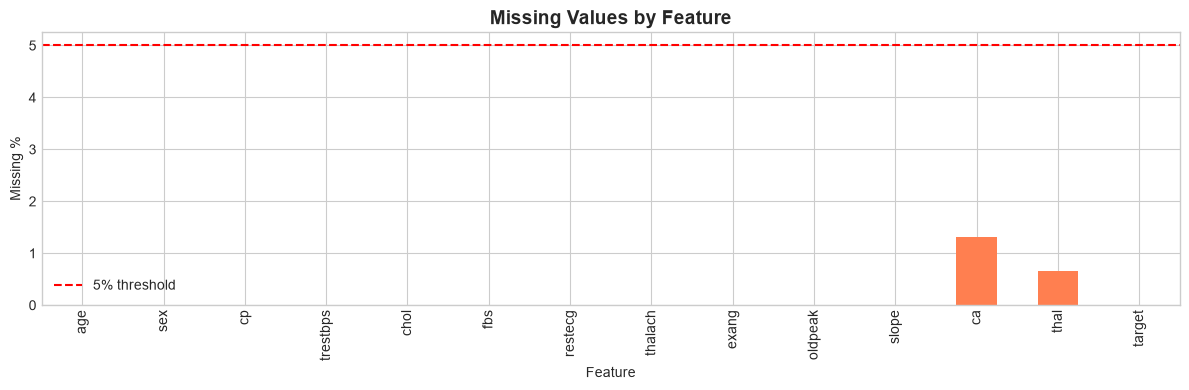

In [8]:
# Visualize missing values (if any)
if missing.sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 4))
    missing_pct.plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Missing %')
    ax.axhline(y=5, color='r', linestyle='--', label='5% threshold')
    plt.legend()
    plt.tight_layout()
    plt.savefig('../screenshots/missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No missing values to visualize!")

## 4. Target Variable Analysis

Understanding the target distribution is crucial for model selection:
- **Balanced dataset**: Standard classification algorithms work well
- **Imbalanced dataset**: May need SMOTE, class weights, or stratified sampling

**Class Balance Ratio** = min_class / max_class
- \> 0.8: Balanced
- 0.5-0.8: Moderately balanced
- < 0.5: Imbalanced (requires special handling)

In [9]:
# Target distribution
target_counts = df['target'].value_counts()
target_pct = df['target'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print("=" * 50)
print(f"No Heart Disease (0): {target_counts[0]} ({target_pct[0]:.1f}%)")
print(f"Heart Disease (1):    {target_counts[1]} ({target_pct[1]:.1f}%)")

# Class balance ratio
balance_ratio = target_counts.min() / target_counts.max()
print(f"\nClass balance ratio: {balance_ratio:.2f}")
print("Status:", "Balanced" if balance_ratio > 0.8 else "Imbalanced" if balance_ratio < 0.5 else "Moderately balanced")

Target Variable Distribution:
No Heart Disease (0): 164 (54.1%)
Heart Disease (1):    139 (45.9%)

Class balance ratio: 0.85
Status: Balanced


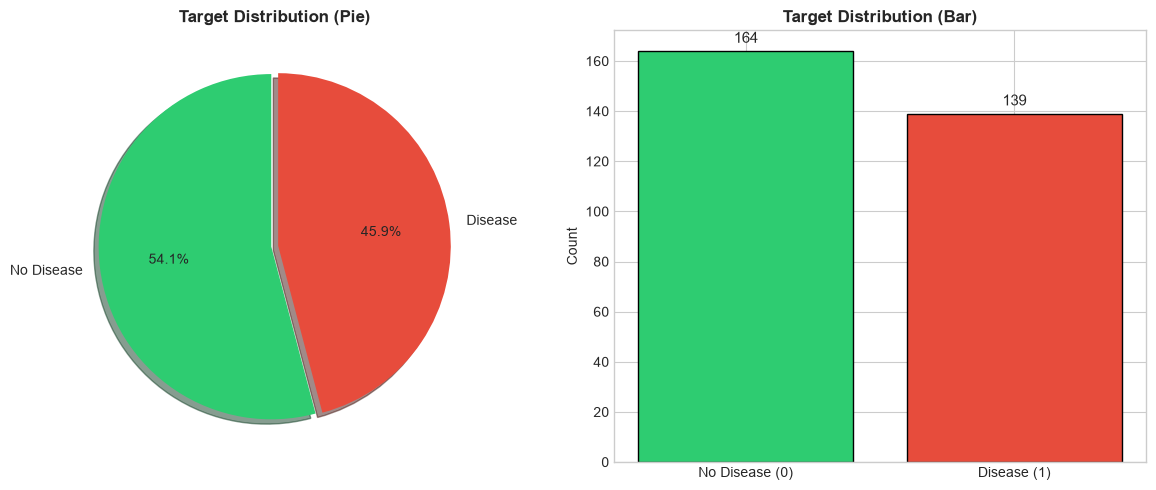

In [10]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(target_counts, labels=['No Disease', 'Disease'], 
            autopct='%1.1f%%', colors=colors, explode=(0.02, 0.02),
            shadow=True, startangle=90)
axes[0].set_title('Target Distribution (Pie)', fontsize=12, fontweight='bold')

# Bar chart
bars = axes[1].bar(['No Disease (0)', 'Disease (1)'], target_counts, color=colors, edgecolor='black')
axes[1].set_title('Target Distribution (Bar)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for bar, count in zip(bars, target_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                 str(count), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../screenshots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Distributions

We analyze two types of features:

### Numeric Features (continuous)
- **age**: Patient age in years
- **trestbps**: Resting blood pressure (mm Hg)
- **chol**: Serum cholesterol (mg/dl)
- **thalach**: Maximum heart rate achieved
- **oldpeak**: ST depression induced by exercise

Histograms with KDE help identify:
- Distribution shape (normal, skewed)
- Potential outliers
- Feature separation between classes

### Categorical Features (discrete)
Binary and multi-class features representing medical conditions and test results.

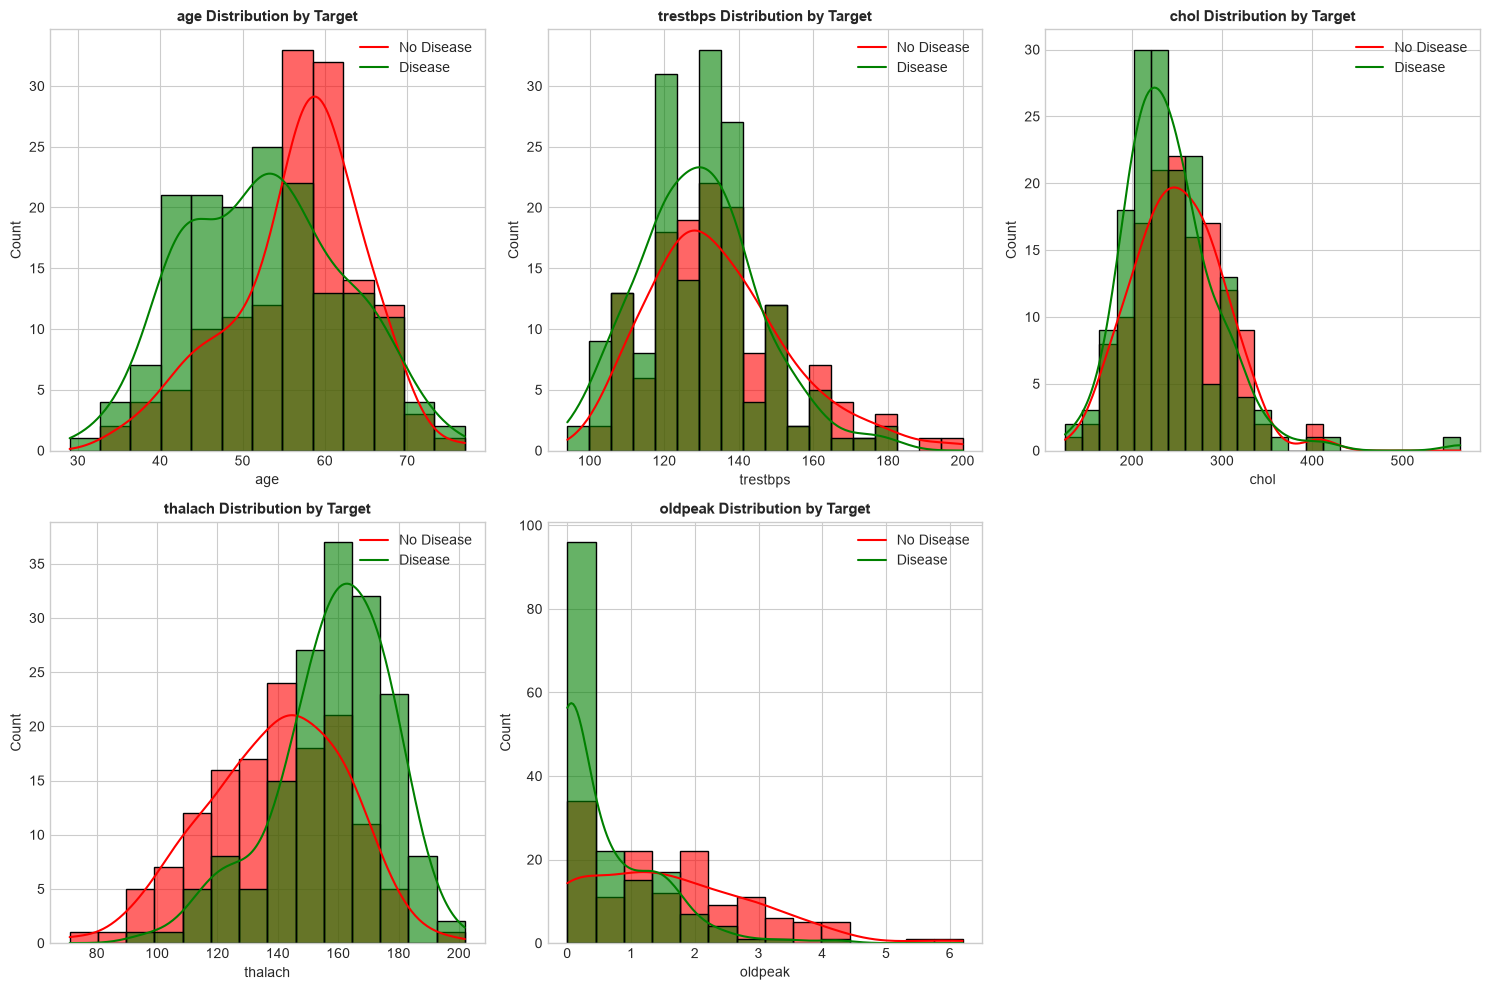

In [11]:
# Numeric features
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    # Histogram with KDE
    sns.histplot(data=df, x=feature, hue='target', kde=True, ax=axes[i], 
                 palette=['green', 'red'], alpha=0.6)
    axes[i].set_title(f'{feature} Distribution by Target', fontsize=11, fontweight='bold')
    axes[i].legend(['No Disease', 'Disease'])

# Remove empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('../screenshots/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

2026-07-06 19:52:43,591 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 19:52:43,594 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 19:52:43,610 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 19:52:43,612 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 19:52:43,628 - INFO - Using categorical units to plot a list of strings that are all parsable as 

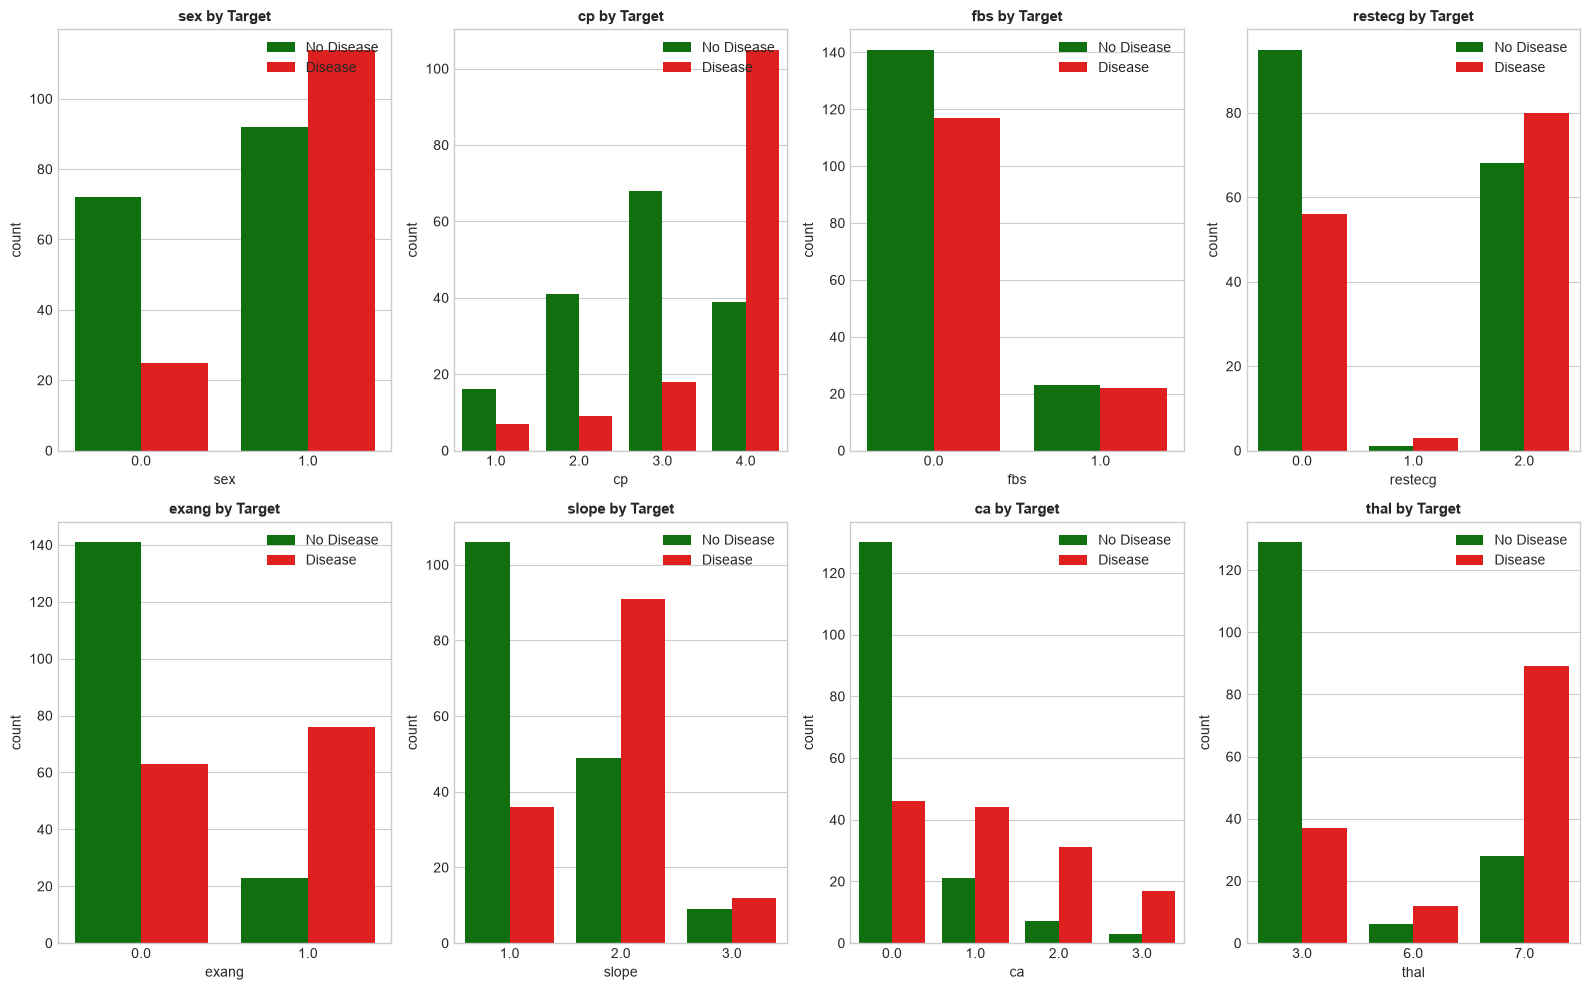

In [12]:
# Categorical features
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    # Count plot
    sns.countplot(data=df, x=feature, hue='target', ax=axes[i], palette=['green', 'red'])
    axes[i].set_title(f'{feature} by Target', fontsize=11, fontweight='bold')
    axes[i].legend(['No Disease', 'Disease'], loc='upper right')

plt.tight_layout()
plt.savefig('../screenshots/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

2026-07-06 19:52:44,635 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 19:52:44,640 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 19:52:44,655 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 19:52:44,658 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 19:52:44,672 - INFO - Using categorical units to plot a list of strings that are all parsable as 

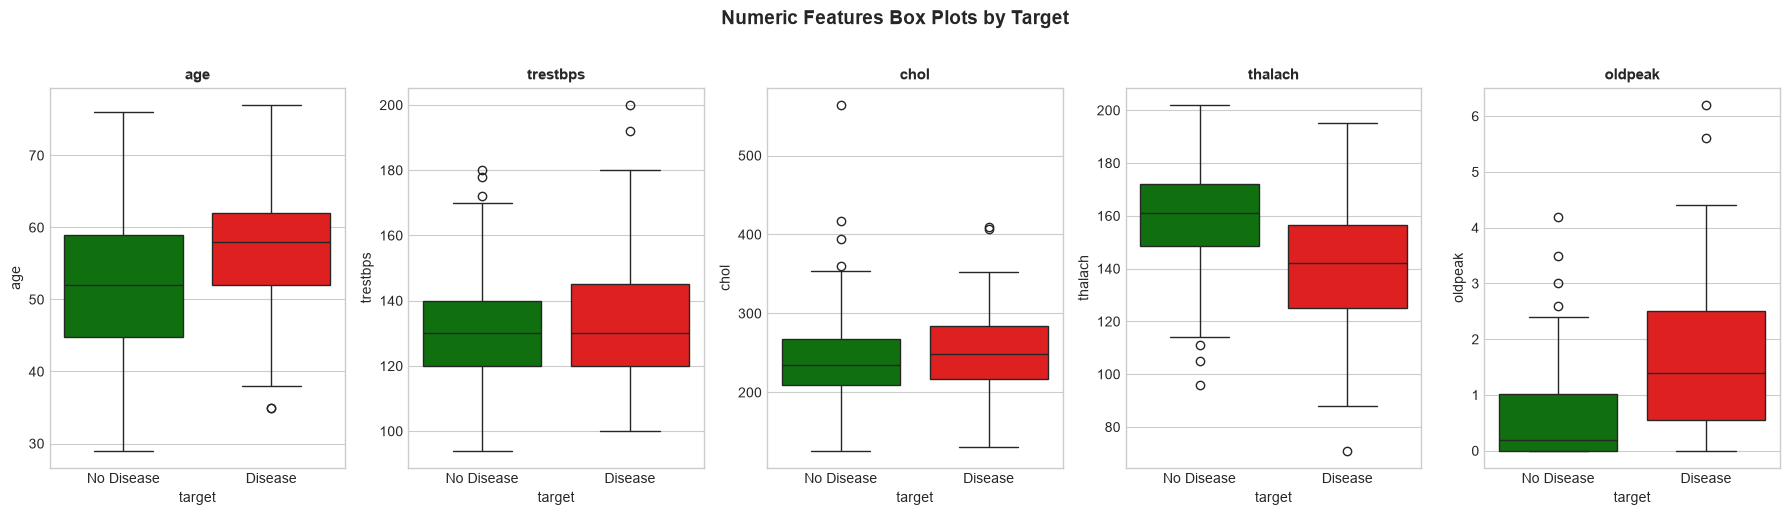

In [13]:
# Box plots for numeric features by target
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, feature in enumerate(numeric_features):
    sns.boxplot(data=df, x='target', y=feature, ax=axes[i], palette=['green', 'red'])
    axes[i].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(['No Disease', 'Disease'])

plt.suptitle('Numeric Features Box Plots by Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Analysis

Correlation analysis identifies relationships between features and the target:

**Interpretation of correlation coefficients:**
- **+1.0**: Perfect positive correlation
- **0.0**: No linear relationship
- **-1.0**: Perfect negative correlation

**Key insights from correlation:**
- Features with |correlation| > 0.3 are typically good predictors
- Multicollinearity (high inter-feature correlation) may affect model interpretability
- The heatmap helps identify feature clusters for feature engineering

In [14]:
# Correlation matrix
correlation_matrix = df.corr()

# Display correlation with target
target_correlation = correlation_matrix['target'].sort_values(ascending=False)
print("Correlation with Target Variable:")
print("=" * 50)
print(target_correlation.round(3))

Correlation with Target Variable:
target      1.000
thal        0.526
ca          0.460
exang       0.432
oldpeak     0.425
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
thalach    -0.417
Name: target, dtype: float64


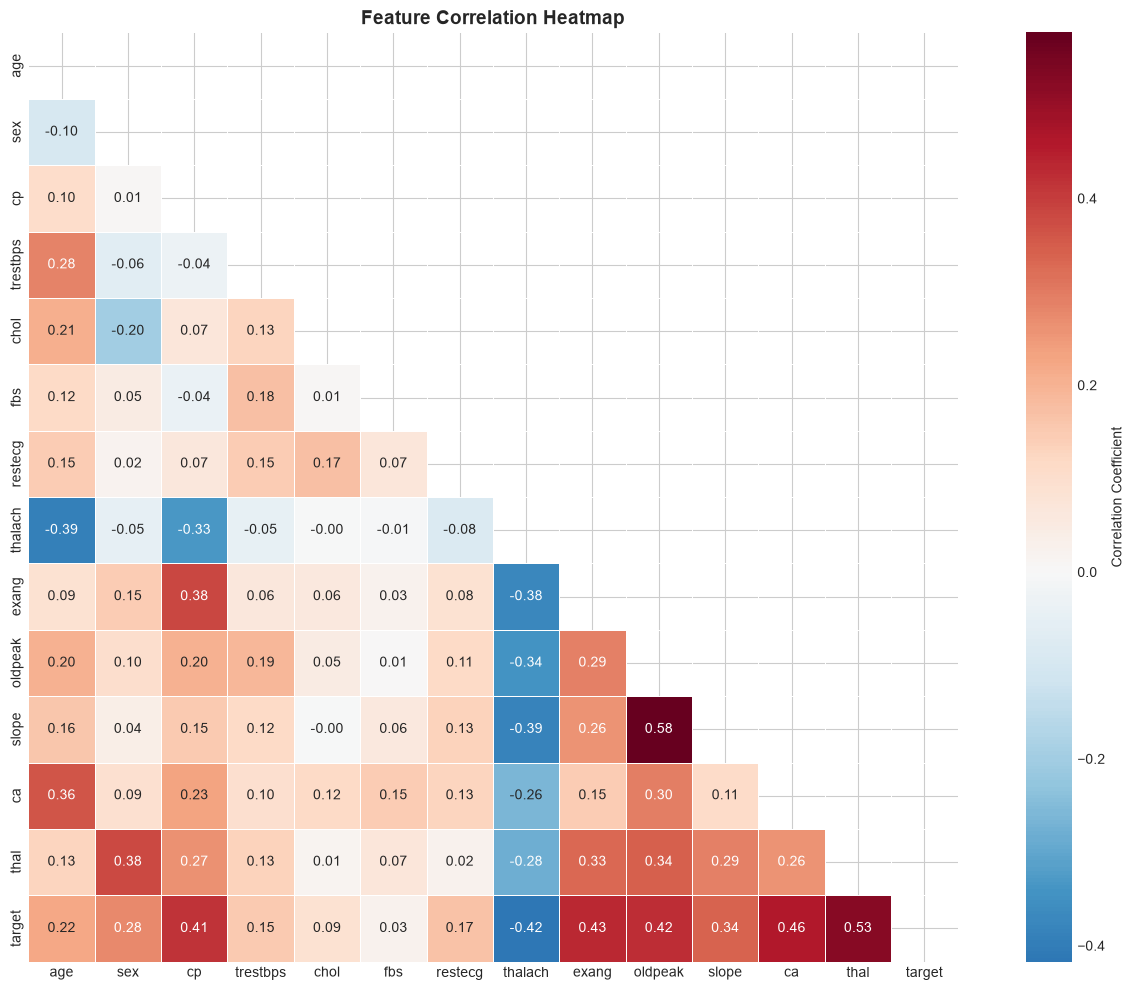

In [15]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

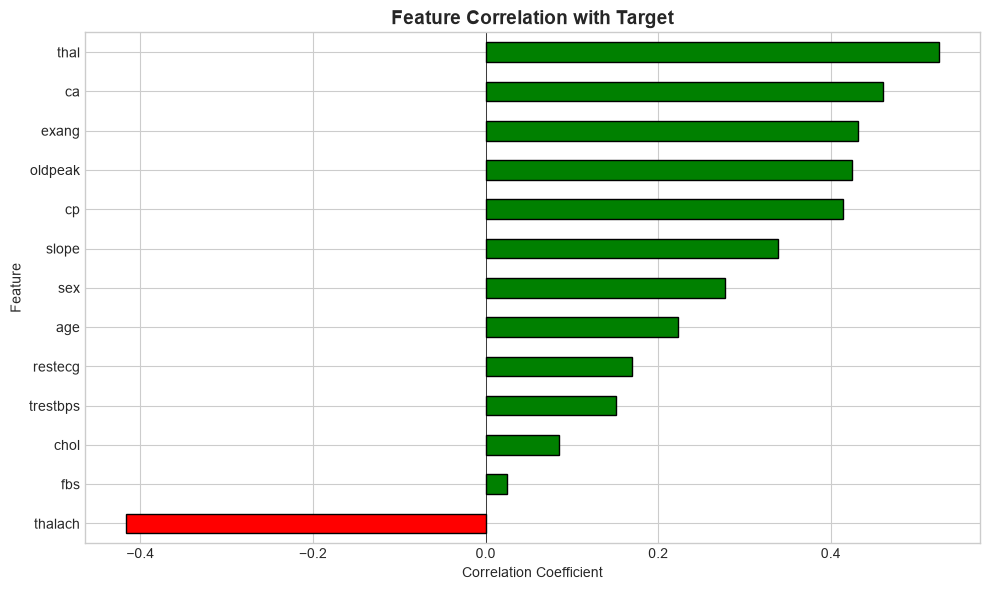

In [16]:
# Target correlation bar chart
fig, ax = plt.subplots(figsize=(10, 6))

target_corr = target_correlation.drop('target').sort_values()
colors = ['red' if x < 0 else 'green' for x in target_corr]

target_corr.plot(kind='barh', color=colors, ax=ax, edgecolor='black')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Feature Correlation with Target', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.savefig('../screenshots/target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Pair Analysis

Pairplots reveal **multi-dimensional relationships** between features:
- **Diagonal**: Distribution of each feature by class (KDE)
- **Off-diagonal**: Scatter plots showing feature interactions
- **Color-coded**: Green (No Disease) vs Red (Disease)

This helps identify:
- Non-linear separability between classes
- Potential feature interactions for feature engineering
- Clusters or outliers in the data

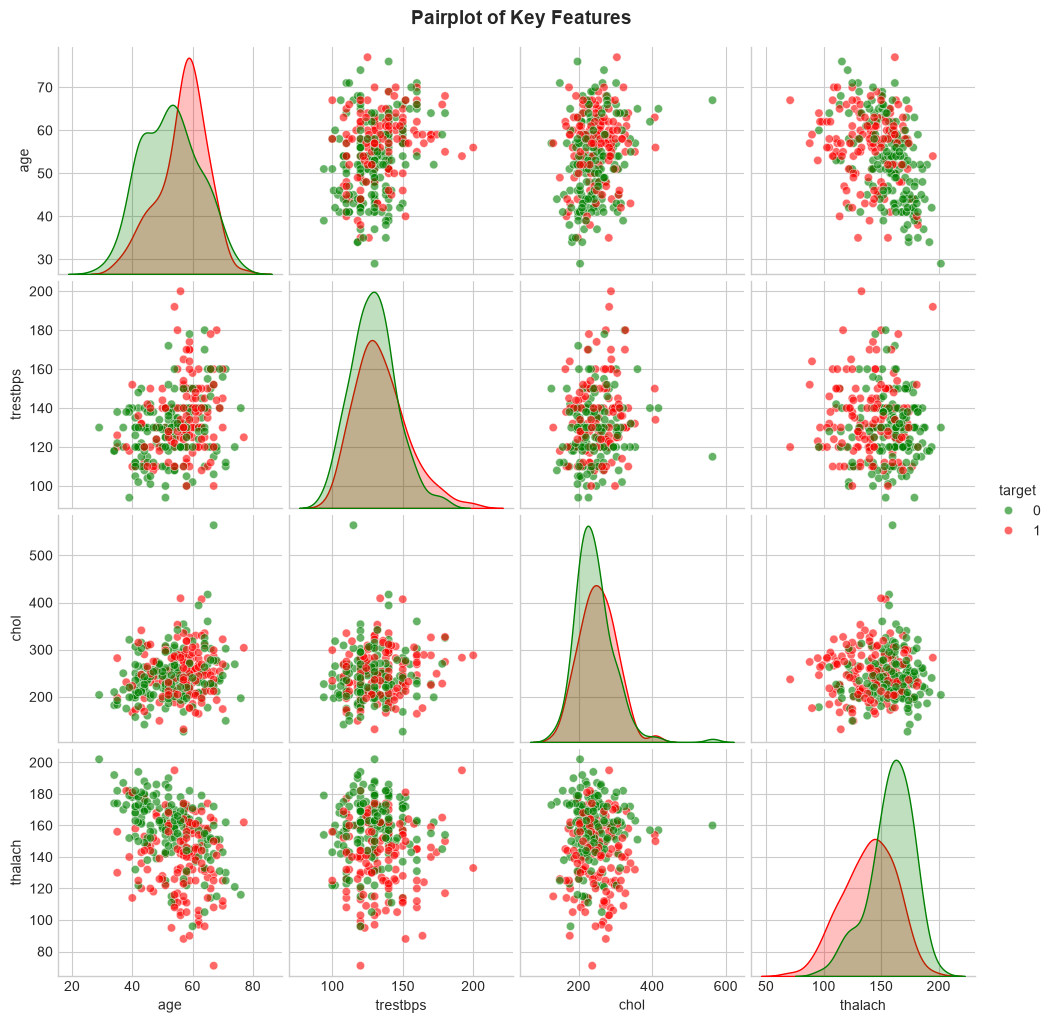

In [17]:
# Pairplot for key features
key_features = ['age', 'trestbps', 'chol', 'thalach', 'target']

g = sns.pairplot(df[key_features], hue='target', 
                 palette=['green', 'red'], 
                 diag_kind='kde',
                 plot_kws={'alpha': 0.6},
                 height=2.5)

g.fig.suptitle('Pairplot of Key Features', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('../screenshots/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Key Insights Summary

This section consolidates the most important findings from our EDA:
1. **Dataset Quality**: Summary of data completeness and integrity
2. **Feature Importance**: Which features show strongest correlation with heart disease
3. **Class Separation**: How well features distinguish disease vs no-disease cases
4. **Actionable Insights**: Recommendations for model training and feature engineering

These insights guide our modeling decisions in the next notebook.

In [18]:
# Summary statistics by target
print("Summary Statistics by Target Class:")
print("=" * 70)

for feature in numeric_features:
    no_disease_mean = df[df['target'] == 0][feature].mean()
    disease_mean = df[df['target'] == 1][feature].mean()
    diff = disease_mean - no_disease_mean
    
    print(f"\n{feature}:")
    print(f"  No Disease Mean: {no_disease_mean:.2f}")
    print(f"  Disease Mean:    {disease_mean:.2f}")
    print(f"  Difference:      {diff:+.2f}")

Summary Statistics by Target Class:

age:
  No Disease Mean: 52.59
  Disease Mean:    56.63
  Difference:      +4.04

trestbps:
  No Disease Mean: 129.25
  Disease Mean:    134.57
  Difference:      +5.32

chol:
  No Disease Mean: 242.64
  Disease Mean:    251.47
  Difference:      +8.83

thalach:
  No Disease Mean: 158.38
  Disease Mean:    139.26
  Difference:      -19.12

oldpeak:
  No Disease Mean: 0.59
  Disease Mean:    1.57
  Difference:      +0.99


In [19]:
# Key insights
print("\n" + "="*70)
print("KEY INSIGHTS FROM EDA")
print("="*70)

insights = [
    "1. Dataset has {} samples with {} features".format(len(df), len(df.columns)-1),
    "2. Target classes are {}".format("balanced" if balance_ratio > 0.8 else "moderately balanced"),
    "3. Most correlated features with heart disease: cp, thalach, exang, oldpeak",
    "4. Age distribution shows higher disease prevalence in older patients",
    "5. Maximum heart rate (thalach) is negatively correlated with disease",
    "6. Chest pain type (cp) shows strong predictive signal",
    "7. Exercise-induced angina (exang) is a significant risk factor",
    "8. ST depression (oldpeak) is higher in patients with heart disease"
]

for insight in insights:
    print(insight)


KEY INSIGHTS FROM EDA
1. Dataset has 303 samples with 13 features
2. Target classes are balanced
3. Most correlated features with heart disease: cp, thalach, exang, oldpeak
4. Age distribution shows higher disease prevalence in older patients
5. Maximum heart rate (thalach) is negatively correlated with disease
6. Chest pain type (cp) shows strong predictive signal
7. Exercise-induced angina (exang) is a significant risk factor
8. ST depression (oldpeak) is higher in patients with heart disease


In [20]:
# Save processed data summary
summary = {
    'total_samples': len(df),
    'features': list(df.columns),
    'target_distribution': df['target'].value_counts().to_dict(),
    'missing_values': df.isnull().sum().sum(),
    'top_correlations': target_correlation.head(5).to_dict()
}

print("\nEDA Summary saved!")
print(f"Total samples: {summary['total_samples']}")
print(f"Missing values: {summary['missing_values']}")


EDA Summary saved!
Total samples: 303
Missing values: 6


## 9. Data Export for Modeling

The final step prepares data for the model training pipeline:

1. **Missing Value Handling**: Apply imputation strategies identified in EDA
2. **Train/Test Split**: 80/20 split with stratification to preserve class balance
3. **Preprocessing Pipeline**: StandardScaler for numeric features
4. **Save to Disk**: Export to `data/processed/` for use in training notebook

**Why stratified split?** 
Ensures both train and test sets have the same class distribution as the original data, preventing sampling bias in model evaluation.

In [21]:
# Save clean data
from src.data.preprocessing import handle_missing_values, prepare_data, save_processed_data

# Handle any missing values
df_clean = handle_missing_values(df)

# Prepare train/test split
X_train, X_test, y_train, y_test, preprocessor = prepare_data(df_clean)

# Save processed data
save_processed_data(X_train, X_test, y_train, y_test)

print("\nData preparation complete!")
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

2026-07-06 19:52:49,677 - INFO - Missing values found:
ca      4
thal    2
dtype: int64
2026-07-06 19:52:49,679 - INFO - Imputed ca with mode: 0.0
2026-07-06 19:52:49,679 - INFO - Imputed thal with mode: 3.0
2026-07-06 19:52:49,722 - INFO - Train set: 242 samples
2026-07-06 19:52:49,723 - INFO - Test set: 61 samples
2026-07-06 19:52:49,724 - INFO - Train target distribution:
target
0    131
1    111
Name: count, dtype: int64
2026-07-06 19:52:49,730 - INFO - Preprocessor fitted successfully
2026-07-06 19:52:49,740 - INFO - Processed data saved to C:\Users\Rajkumar Madhavan\OneDrive\Desktop\MLOPS\MLOPS-Assignment\notebooks\..\data\processed



Data preparation complete!
Training set: 242 samples
Test set: 61 samples
